# **# **Netflix Recommendation Engine**

**What are Recommender Systems?**

Recommender systems are algorithms designed to suggest relevant items to users. These systems are used in various domains such as e-commerce, streaming services, and social media. They enhance user experience by filtering vast amounts of information to deliver personalized content.
**

#SVD (Singular Value Decomposition) in a recommendation system works by finding patterns in user preferences and item similarities.

Here's a basic idea without going deep into the topic

**1) What the System Has: A big table (matrix) with users on one side and items (like movies) on the other. Users give ratings to items, but not everyone has rated everything**

**2) What SVD Does: SVD looks at the ratings that are available and tries to figure out the hidden connections between users and items. It learns what kind of movies users like based on their previous ratings**

**3) How It Helps: Once SVD understands these patterns, it can predict how a user might rate a movie they haven’t seen yet. Based on these predictions, the system recommends movies that the user is most likely to enjoy**

In [ ]:
!pip uninstall -y numpy
#surprise works only with NumPy 1.x                   # Uninstall the current version of Numpy
!pip install numpy==1.26.4                           # Install numpy version 1.26.4
!pip install scikit-surprise --prefer-binary         # Install surprise library now

#scikit-surprise (or simply Surprise) is a Python library used to build Recommendation Systems.
#It is mainly used for collaborative filtering — like Netflix, Amazon, YouTube recommendations.

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
tobler 0.13.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 req

  Using cached scikit_surprise-1.1.4.tar.gz (154 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-surprise: filename=scikit_surprise-1.1.4-cp312-cp312-linux_x86_64.whl size=2554992 sha256=4195b24f01b63a5fa5726c71e48839ef313402132c11ebdbf0133b812766cdfd
  Stored in directory: /root/.cache/pip/wheels/75/fa/bc/739bc2cb1fbaab6061854e6cfbb81a0ae52c92a502a7fa454b
Successfully built scikit-surprise


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Reading dataset file having 2 crore 40 lakh 58 thousand records

netflix_dataset = pd.read_csv('/content/combined_data_1.txt',header = None, names = ['Cust_Id', 'Rating'], usecols = [0,1])
netflix_dataset

,Cust_Id,Rating
0,1:,NaN
1,1488844,3.0
2,822109,5.0
3,885013,4.0
4,30878,4.0
...,...,...
24058258,2591364,2.0
24058259,1791000,2.0
24058260,512536,5.0
24058261,988963,3.0


In [ ]:
netflix_dataset.tail()

,Cust_Id,Rating
24058258,2591364,2.0
24058259,1791000,2.0
24058260,512536,5.0
24058261,988963,3.0
24058262,1704416,3.0


In [ ]:
netflix_dataset.dtypes

,0
Cust_Id,object
Rating,float64


In [ ]:
netflix_dataset.isnull().sum()

,0
Cust_Id,0
Rating,4499


# Finding the movie count by assumiung that if there is NaN in Rating column so in front of it , there is a movie id

In [ ]:
#get the movie count ( as the NaN values in Rating column will show how many movie are there )
movie_count=netflix_dataset.isnull().sum()
movie_count=movie_count["Rating"]
movie_count

4499

# Finding the total unqiue customer id by substracting the movie count from uniuque values in cust id column

In [ ]:
#to claculate how many customers we are having in the dataset
customer_count=netflix_dataset['Cust_Id'].nunique()
customer_count

475257

In [ ]:
customer_count - movie_count  # Total number of customers that we have after removing movie id from the column

470758

**we have totak 4 lakh , 70 thousand and 7 hundred 58 unique customeras**

In [ ]:
#get the total number of ratings given by the customers to all movies combined

rating_count=netflix_dataset['Cust_Id'].count()-movie_count  # In Customer id column we will remove movie id to get how many total rating are there
rating_count

24053764

In [ ]:
#To find out how many people have rated the movies as 1, 2, 3,4,5 stars ratings to the movies
stars=netflix_dataset.groupby('Rating')['Rating'].agg(['count'])
stars

,count
Rating,
1.0,1118186
2.0,2439073
3.0,6904181
4.0,8085741
5.0,5506583


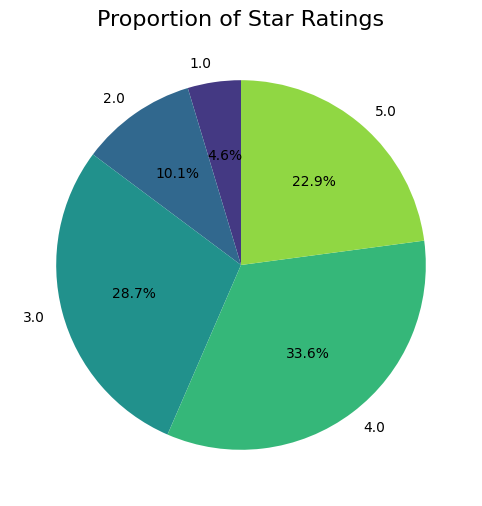

In [ ]:
plt.figure(figsize=(8, 6))
plt.pie(stars['count'], labels=stars.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('viridis', len(stars)))
plt.title('Proportion of Star Ratings', fontsize=16)
plt.show()

## Insights from Rating Distribution Plots

From the generated bar chart, pie chart, and line plot, we can observe the following key insights regarding the distribution of 1 to 5-star ratings:

1.  **Dominance of Higher Ratings**: The majority of ratings are concentrated in the higher star categories (3, 4, and 5 stars). This is clearly visible in all three plots.

2.  **Peak at 4 Stars**: The 4-star rating is the most frequent, closely followed by 3-star ratings. The line plot vividly shows this trend, peaking at 4 stars.

3.  **Significant Number of 5-Star Ratings**: Although not the highest, 5-star ratings constitute a substantial portion, indicating a good number of highly satisfied users.

4.  **Fewer Low Ratings**: 1-star and 2-star ratings are considerably less frequent compared to higher ratings. This suggests that users generally have a positive or neutral experience with the movies they rate.

5.  **Proportional Distribution**: The pie chart quantifies these observations, showing the percentage contribution of each rating, where 3-star and 4-star ratings together account for more than half of all ratings.

Overall, the distribution indicates a positive sentiment among users, with a strong preference for 3-star and 4-star ratings, and fewer instances of very low ratings.

In [ ]:
# Lets just make a clear dataframe to find how many MovieId are there
movie_id=None
movie_np =[]
# Iterate over the DataFrame rows
for cust_id in netflix_dataset['Cust_Id']:
    if ':' in cust_id:
      # Update the current movie ID
      movie_id = int(cust_id.replace(':', ''))
    movie_np.append(movie_id)

In [ ]:
movie_np

[1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,


In [ ]:
# Add the new column to the DataFrame
netflix_dataset['Movie_Id'] = movie_np
netflix_dataset

,Cust_Id,Rating,Movie_Id
0,1:,NaN,1
1,1488844,3.0,1
2,822109,5.0,1
3,885013,4.0,1
4,30878,4.0,1
...,...,...,...
24058258,2591364,2.0,4499
24058259,1791000,2.0,4499
24058260,512536,5.0,4499
24058261,988963,3.0,4499


In [ ]:
netflix_dataset = netflix_dataset[netflix_dataset['Rating'].notna()]
# to keep only the rows where the 'Rating' column is not null (i.e., it excludes rows where the 'Rating' is NaN)
netflix_dataset

,Cust_Id,Rating,Movie_Id
1,1488844,3.0,1
2,822109,5.0,1
3,885013,4.0,1
4,30878,4.0,1
5,823519,3.0,1
...,...,...,...
24058258,2591364,2.0,4499
24058259,1791000,2.0,4499
24058260,512536,5.0,4499
24058261,988963,3.0,4499


In [ ]:
netflix_dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24053764 entries, 1 to 24058262
Data columns (total 3 columns):
 #   Column    Dtype  
---  ------    -----  
 0   Cust_Id   object 
 1   Rating    float64
 2   Movie_Id  int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 734.1+ MB


In [ ]:
netflix_dataset.describe()

,Rating,Movie_Id
count,2.405376e+07,2.405376e+07
mean,3.599634e+00,2.308324e+03
std,1.086118e+00,1.303909e+03
min,1.000000e+00,1.000000e+00
25%,3.000000e+00,1.180000e+03
50%,4.000000e+00,2.342000e+03
75%,4.000000e+00,3.433000e+03
max,5.000000e+00,4.499000e+03


In [ ]:
# Now we dont hav movie if in cust id column we have removed all 1:Nan , 2:Nan so lets fix the data type now
netflix_dataset["Cust_Id"]=netflix_dataset["Cust_Id"].astype(int)

/tmp/ipykernel_782/280181150.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  netflix_dataset["Cust_Id"]=netflix_dataset["Cust_Id"].astype(int)


In [ ]:
netflix_dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24053764 entries, 1 to 24058262
Data columns (total 3 columns):
 #   Column    Dtype  
---  ------    -----  
 0   Cust_Id   int64  
 1   Rating    float64
 2   Movie_Id  int64  
dtypes: float64(1), int64(2)
memory usage: 734.1 MB


In [ ]:
#pre-filtering
#now we will remove all the users that have rated less movies and
#also all those movies that has been rated less in numbers

In [ ]:
dataset_movie_summary=netflix_dataset.groupby('Movie_Id')['Rating'].agg(["count"])

In [ ]:
dataset_movie_summary

,count
Movie_Id,
1,547
2,145
3,2012
4,142
5,1140
...,...
4495,614
4496,9519
4497,714


In [ ]:
#now we will create a benchmark
movie_benchmark=round(dataset_movie_summary['count'].quantile(0.6),0)
movie_benchmark

908.0

In [ ]:
drop_movie_list=dataset_movie_summary[dataset_movie_summary['count']<movie_benchmark].index
drop_movie_list  # In this lst all movies are there those are having less rating then bencmarsk so reove them

Index([   1,    2,    4,    7,    9,   10,   11,   12,   13,   14,
       ...
       4480, 4481, 4486, 4487, 4491, 4494, 4495, 4497, 4498, 4499],
      dtype='int64', name='Movie_Id', length=2699)

In [ ]:
4499-2699  #movies left

1800

In [ ]:
#now we will remove all the users that are in-active
dataset_cust_summary=netflix_dataset.groupby('Cust_Id')['Rating'].agg(["count"])
dataset_cust_summary

,count
Cust_Id,
6,153
7,195
8,21
10,49
25,4
...,...
2649404,12
2649409,10
2649421,3


In [ ]:
cust_benchmark=round(dataset_cust_summary['count'].quantile(0.6),0)
cust_benchmark

36.0

In [ ]:
drop_cust_list=dataset_cust_summary[dataset_cust_summary['count']<cust_benchmark].index
drop_cust_list

Index([      8,      25,      33,      83,      94,     126,     130,     133,
           142,     149,
       ...
       2649337, 2649343, 2649351, 2649376, 2649379, 2649384, 2649401, 2649404,
       2649409, 2649421],
      dtype='int64', name='Cust_Id', length=282042)

In [ ]:
# Lets remove all movies that has been rated less than 908 times

# Lets remove all customers that have rated less than 36 movies

In [ ]:
netflix_dataset=netflix_dataset[~netflix_dataset['Movie_Id'].isin(drop_movie_list)]
netflix_dataset=netflix_dataset[~netflix_dataset['Cust_Id'].isin(drop_cust_list)]
print('After the droping, the shape is: {}'.format(netflix_dataset.shape))

After the droping, the shape is: (19695836, 3)


In [ ]:
netflix_dataset  # Clean netflix data

,Cust_Id,Rating,Movie_Id
696,712664,5.0,3
697,1331154,4.0,3
698,2632461,3.0,3
699,44937,5.0,3
700,656399,4.0,3
...,...,...,...
24056842,1055714,5.0,4496
24056843,2643029,4.0,4496
24056844,267802,4.0,4496
24056845,1559566,3.0,4496


In [ ]:
netflix_dataset.head(50)

,Cust_Id,Rating,Movie_Id
696,712664,5.0,3
697,1331154,4.0,3
698,2632461,3.0,3
699,44937,5.0,3
700,656399,4.0,3
701,439011,1.0,3
702,1436762,3.0,3
703,1644750,3.0,3
704,2031561,4.0,3
705,616720,4.0,3


In [ ]:
movie_id

4499

# **Model Building**

In [ ]:
title = pd.read_csv("/content/movie_titles _1_.csv",   encoding='latin',header=None, usecols=[0,1,2], names=['Movie_Id','Year','Name' ])

In [ ]:
title

,Movie_Id,Year,Name
0,1,2003.0,Dinosaur Planet
1,2,2004.0,Isle of Man TT 2004 Review
2,3,1997.0,Character
3,4,1994.0,Paula Abdul's Get Up & Dance
4,5,2004.0,The Rise and Fall of ECW
...,...,...,...
17765,17766,2002.0,Where the Wild Things Are and Other Maurice Se...
17766,17767,2004.0,Fidel Castro: American Experience
17767,17768,2000.0,Epoch
17768,17769,2003.0,The Company


In [ ]:
 #Install numpy
!pip install surprise

In [ ]:
from surprise import Reader, Dataset, SVD
from surprise.model_selection import cross_validate

In [ ]:
reader=Reader()

In [ ]:
#we only work with top 100K rows for quick runtime
data=  Dataset.load_from_df(netflix_dataset[['Cust_Id','Movie_Id','Rating']][:100000], reader)

In [ ]:
data

In [ ]:
model=SVD()  # Creating a SVD model

In [ ]:
cross_validate(model, data, measures=['RMSE'], cv=3)  # Trained the model

{'test_rmse': array([1.02250831, 1.0187686 , 1.0144227 ]),
 'fit_time': (5.205878257751465, 1.8006737232208252, 1.7276434898376465),
 'test_time': (1.163865327835083, 0.1703784465789795, 0.27709317207336426)}

# **Use model for making Recommendation for a specific user**

In [ ]:
# Filter the dataset for the specific user you have selected to make recommendation to that user
user_ratings = netflix_dataset[netflix_dataset['Cust_Id'] == 1331154]
user_ratings

,Cust_Id,Rating,Movie_Id
697,1331154,4.0,3
5178,1331154,4.0,8
31460,1331154,3.0,18
92840,1331154,4.0,30
224761,1331154,3.0,44
...,...,...,...
23439584,1331154,4.0,4389
23546489,1331154,2.0,4402
23649431,1331154,4.0,4432
23844441,1331154,3.0,4472


In [ ]:
# Find the number of unique movies rated by the user
movies_rated_by_user = user_ratings['Movie_Id'].nunique()

print(f"User 1331154 has rated {movies_rated_by_user} unique movies.")

User 1331154 has rated 253 unique movies.


In [ ]:
copy_data_for_user =title.copy()   #making a copy for each individual customer for the recomendation
copy_data_for_user

,Movie_Id,Year,Name
0,1,2003.0,Dinosaur Planet
1,2,2004.0,Isle of Man TT 2004 Review
2,3,1997.0,Character
3,4,1994.0,Paula Abdul's Get Up & Dance
4,5,2004.0,The Rise and Fall of ECW
...,...,...,...
17765,17766,2002.0,Where the Wild Things Are and Other Maurice Se...
17766,17767,2004.0,Fidel Castro: American Experience
17767,17768,2000.0,Epoch
17768,17769,2003.0,The Company


In [ ]:
CLEAN_copy_data_for_user = copy_data_for_user[~copy_data_for_user['Movie_Id'].isin(drop_movie_list)]
CLEAN_copy_data_for_user   # Removing the movie les then benchmark for this user

,Movie_Id,Year,Name
2,3,1997.0,Character
4,5,2004.0,The Rise and Fall of ECW
5,6,1997.0,Sick
7,8,2004.0,What the #$*! Do We Know!?
15,16,1996.0,Screamers
...,...,...,...
17765,17766,2002.0,Where the Wild Things Are and Other Maurice Se...
17766,17767,2004.0,Fidel Castro: American Experience
17767,17768,2000.0,Epoch
17768,17769,2003.0,The Company


In [ ]:
CLEAN_copy_data_for_user['Estimate_Score']=CLEAN_copy_data_for_user['Movie_Id'].apply(lambda x: model.predict(1331154, x).est)
# predict the score (rating) that a user (with user ID 1331154) might give to a list of movies.
# core thing

/tmp/ipykernel_782/2454269427.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  CLEAN_copy_data_for_user['Estimate_Score']=CLEAN_copy_data_for_user['Movie_Id'].apply(lambda x: model.predict(1331154, x).est)


In [ ]:
CLEAN_copy_data_for_user

,Movie_Id,Year,Name,Estimate_Score
2,3,1997.0,Character,3.505741
4,5,2004.0,The Rise and Fall of ECW,3.784061
5,6,1997.0,Sick,2.694083
7,8,2004.0,What the #$*! Do We Know!?,3.510874
15,16,1996.0,Screamers,2.855019
...,...,...,...,...
17765,17766,2002.0,Where the Wild Things Are and Other Maurice Se...,3.505472
17766,17767,2004.0,Fidel Castro: American Experience,3.505472
17767,17768,2000.0,Epoch,3.505472
17768,17769,2003.0,The Company,3.505472


In [ ]:
CLEAN_copy_data_for_user.sort_values('Estimate_Score', ascending=False) # Descending order estimated score

,Movie_Id,Year,Name,Estimate_Score
24,25,1997.0,Inspector Morse 31: Death Is Now My Neighbour,4.167897
4,5,2004.0,The Rise and Fall of ECW,3.784061
17,18,1994.0,Immortal Beloved,3.646808
27,28,2002.0,Lilo and Stitch,3.537748
29,30,2003.0,Something's Gotta Give,3.521747
...,...,...,...,...
25,26,2004.0,Never Die Alone,3.126368
15,16,1996.0,Screamers,2.855019
23,24,1981.0,My Bloody Valentine,2.791880
5,6,1997.0,Sick,2.694083


In [ ]:
top10_movies=CLEAN_copy_data_for_user.sort_values('Estimate_Score', ascending=False).head(10)

In [ ]:
top10_movies

,Movie_Id,Year,Name,Estimate_Score
24,25,1997.0,Inspector Morse 31: Death Is Now My Neighbour,4.167897
4,5,2004.0,The Rise and Fall of ECW,3.784061
17,18,1994.0,Immortal Beloved,3.646808
27,28,2002.0,Lilo and Stitch,3.537748
29,30,2003.0,Something's Gotta Give,3.521747
7,8,2004.0,What the #$*! Do We Know!?,3.510874
2,3,1997.0,Character,3.505741
12743,12744,1969.0,Who's That Knocking at My Door?,3.505472
12742,12743,1989.0,Black Rain,3.505472
12744,12745,1986.0,River's Edge,3.505472
